### Build a `sentiment analysis model` using `Recurrent Neural Networks (RNNs)` to
### classify movie reviews from the `IMDB dataset` into positive or negative sentiments

#### `Data Preprocessing`:

Load the IMDB dataset, keeping only the top 10,000 most frequently occurring words.

Pad the sequences so that they all have the same length.

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.datasets import imdb
from keras.preprocessing import sequence
import matplotlib.pyplot as plt

In [2]:
max_features=10000
max_len=150

In [3]:
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=max_features)

In [4]:
y_test

array([0, 1, 1, ..., 0, 0, 0], dtype=int64)

In [5]:
X_train, X_test=sequence.pad_sequences(X_train,maxlen=max_len), sequence.pad_sequences(X_test,maxlen=max_len)

#### `Model Building:`

● Create a Sequential RNN model using TensorFlow and Keras.

● The model should consist of an Embedding layer, a SimpleRNN layer, and a Dense output layer.

● Compile the model, specifying the appropriate optimizer, loss function, and metrics

In [6]:
model=models.Sequential()
model.add(layers.Embedding(input_dim=max_features, output_dim=32))
model.add(layers.SimpleRNN(units=32))
model.add(layers.Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 32)          320000    
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                2080      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 322113 (1.23 MB)
Trainable params: 322113 (1.23 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### `Training`:

Train the model on the preprocessed movie reviews, using a batch size of 128 and validating on 20% of the training data.

Run the training for 10 epochs.

In [7]:
history= model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
157/157 [==============================] - 32s 162ms/step - loss: 0.5351 - accuracy: 0.7227 - val_loss: 0.4603 - val_accuracy: 0.7892
Epoch 2/10
157/157 [==============================] - 24s 154ms/step - loss: 0.3099 - accuracy: 0.8740 - val_loss: 0.3504 - val_accuracy: 0.8478
Epoch 3/10
157/157 [==============================] - 23s 146ms/step - loss: 0.2180 - accuracy: 0.9197 - val_loss: 0.3739 - val_accuracy: 0.8358
Epoch 4/10
157/157 [==============================] - 23s 147ms/step - loss: 0.1456 - accuracy: 0.9514 - val_loss: 0.3790 - val_accuracy: 0.8470
Epoch 5/10
157/157 [==============================] - 22s 141ms/step - loss: 0.0913 - accuracy: 0.9737 - val_loss: 0.4387 - val_accuracy: 0.8446
Epoch 6/10
157/157 [==============================] - 22s 140ms/step - loss: 0.0520 - accuracy: 0.9869 - val_loss: 0.5000 - val_accuracy: 0.8400
Epoch 7/10
157/157 [==============================] - 22s 142ms/step - loss: 0.0324 - accuracy: 0.9919 - val_loss: 0.5689 - val_ac

#### `Evaluation:`

Evaluate the model on the test set and report the accuracy.

In [8]:
testing_loss, testing_accuracy= model.evaluate(X_test, y_test)
print(testing_loss, testing_accuracy)

782/782 [==============================] - 17s 22ms/step - loss: 0.6441 - accuracy: 0.8294
0.6440641283988953 0.8294000029563904


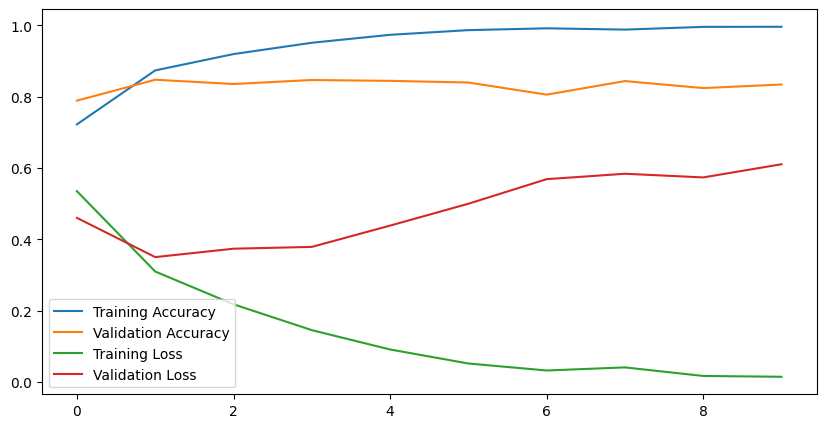

In [9]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

In [10]:
predictions=model.predict(X_test)
sentiment=[]
for i in predictions:
    if i>0.5:
        sentiment.append(1)
    else:
        sentiment.append(0)

782/782 [==============================] - 17s 21ms/step


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix
confusion_matrix(y_test, sentiment)

array([[10372,  2128],
       [ 2137, 10363]], dtype=int64)

In [12]:
accuracy_score(y_test, sentiment)

0.8294

#### Expected Outcome:

A trained RNN model that can classify movie reviews into positive or negative

sentiments, with an accuracy metric provided at the end of the training process